# Лабораторная работа 4

## Классификация цветов автомобилей

План:

1. Проверить структуру датасета.
2. Сравнить две предобученные модели.
3. Сравнить их с собственной CNN, обученной с нуля.
4. Оценить качество по `F1_macro` и сделать вывод.

In [20]:
%matplotlib inline

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = Path.cwd()
artifacts_root = project_root / "artifacts" / "lab4"
manifest_path = project_root / "data" / "prepared_lab4" / "manifest.json"

with manifest_path.open(encoding="utf-8") as file:
    manifest = json.load(file)

summary = pd.read_csv(artifacts_root / "results_summary.csv")
distribution = pd.read_csv(artifacts_root / "class_distribution.csv")
imagenet_report = pd.read_csv(artifacts_root / "vit_b16_imagenet_report.csv")
swag_report = pd.read_csv(artifacts_root / "vit_b16_swag_report.csv")
scratch_report = pd.read_csv(artifacts_root / "from_scratch_report.csv")
scratch_history = pd.read_csv(artifacts_root / "scratch_history.csv")

with (artifacts_root / "vit_b16_imagenet_metrics.json").open(encoding="utf-8") as file:
    imagenet_metrics = json.load(file)

with (artifacts_root / "vit_b16_swag_metrics.json").open(encoding="utf-8") as file:
    swag_metrics = json.load(file)

with (artifacts_root / "scratch_metrics.json").open(encoding="utf-8") as file:
    scratch_metrics = json.load(file)

with (artifacts_root / "scratch_stats.json").open(encoding="utf-8") as file:
    scratch_stats = json.load(file)

with (artifacts_root / "conclusion.json").open(encoding="utf-8") as file:
    conclusion = json.load(file)

display(Markdown(f"**Классы:** {', '.join(manifest['classes'])}"))
display(Markdown(f"**Размеры сплитов:** train = {distribution.query('split == \"train\"')['count'].sum()}, val = {distribution.query('split == \"val\"')['count'].sum()}, test = {distribution.query('split == \"test\"')['count'].sum()}"))

**Классы:** Black, Blue, Grey, Red, Silver, White

**Размеры сплитов:** train = 2520, val = 540, test = 540

## Распределение данных

Датасет сбалансирован по цветам, поэтому сравнение моделей получается корректным.

split,test,train,val
class_name,,,
Black,90,420,90
Blue,90,420,90
Grey,90,420,90
Red,90,420,90
Silver,90,420,90
White,90,420,90


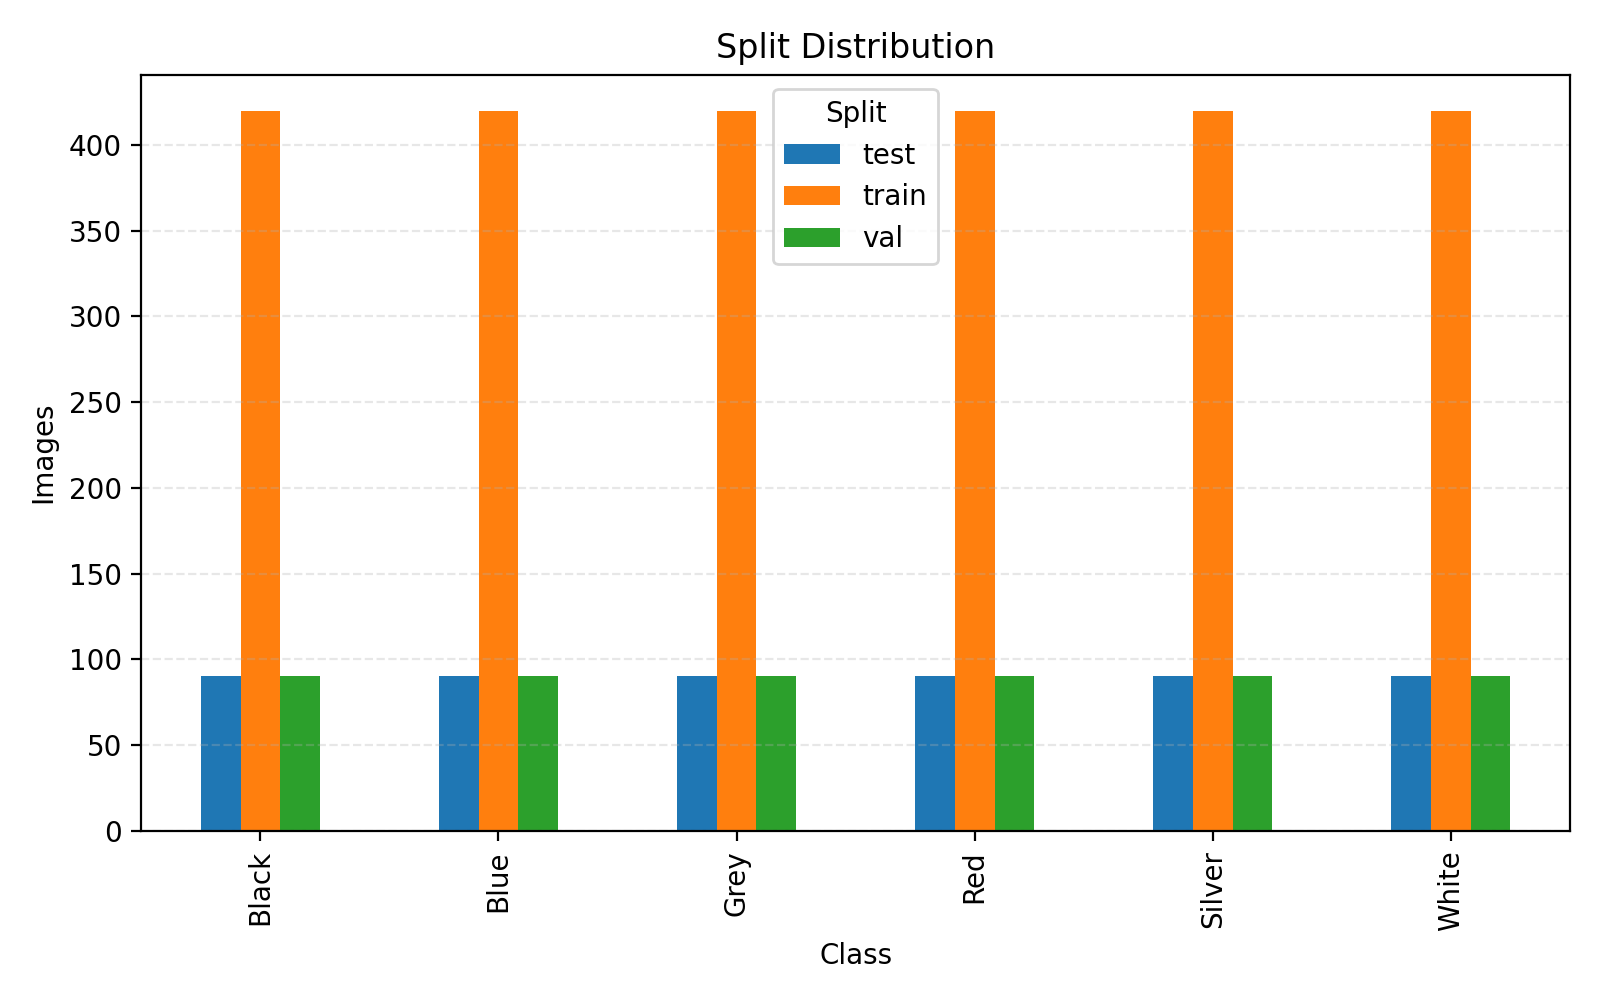

In [21]:
distribution_pivot = distribution.pivot(index="class_name", columns="split", values="count")
display(distribution_pivot)
display(Image(filename=str(artifacts_root / "class_distribution.png")))

## Модели

Использованы три простых варианта:

- `vit_b16_imagenet` — признаки `ViT-B/16` с весами `ImageNet` и линейный классификатор.
- `vit_b16_swag` — признаки `ViT-B/16` с весами `SWAG` и линейный классификатор.
- `scratch_cnn` — компактная CNN, обученная с нуля.

In [22]:
summary_rounded = summary.copy()
summary_rounded["test_accuracy"] = summary_rounded["test_accuracy"].round(4)
summary_rounded["test_f1_macro"] = summary_rounded["test_f1_macro"].round(4)
display(summary_rounded)

metrics_frame = pd.DataFrame([
    imagenet_metrics,
    swag_metrics,
    scratch_metrics,
])
display(metrics_frame)

,model,test_accuracy,test_f1_macro
0,vit_b16_swag,0.8111,0.8137
1,vit_b16_imagenet,0.7963,0.7960
2,scratch_cnn,0.7556,0.7554


,model,weights,selected_c,val_f1_macro,test_accuracy,test_f1_macro,best_val_f1_macro,best_epoch
0,vit_b16_imagenet,IMAGENET1K_V1,0.1,0.829445,0.796296,0.796030,NaN,NaN
1,vit_b16_swag,IMAGENET1K_SWAG_E2E_V1,0.1,0.791048,0.811111,0.813715,NaN,NaN
2,scratch_cnn,NaN,NaN,NaN,0.755556,0.755390,0.769263,11.0


## Отчёты по классам

Ниже видно, что лучше всего модели определяют `Red`, а хуже всего обычно определяют `Grey`.

In [23]:
report_columns = ["label", "precision", "recall", "f1-score", "support"]

display(Markdown("### ViT-B/16 ImageNet"))
display(imagenet_report[report_columns])

display(Markdown("### ViT-B/16 SWAG"))
display(swag_report[report_columns])

display(Markdown("### Scratch CNN"))
display(scratch_report[report_columns])

### ViT-B/16 ImageNet

,label,precision,recall,f1-score,support
0,Black,0.767442,0.733333,0.750000,90.000000
1,Blue,0.781609,0.755556,0.768362,90.000000
2,Grey,0.625000,0.611111,0.617978,90.000000
3,Red,1.000000,0.988889,0.994413,90.000000
4,Silver,0.724490,0.788889,0.755319,90.000000
5,White,0.880435,0.900000,0.890110,90.000000
6,accuracy,0.796296,0.796296,0.796296,0.796296
7,macro avg,0.796496,0.796296,0.796030,540.000000
8,weighted avg,0.796496,0.796296,0.796030,540.000000


### ViT-B/16 SWAG

,label,precision,recall,f1-score,support
0,Black,0.858974,0.744444,0.797619,90.000000
1,Blue,0.848837,0.811111,0.829545,90.000000
2,Grey,0.607843,0.688889,0.645833,90.000000
3,Red,0.988889,0.988889,0.988889,90.000000
4,Silver,0.704082,0.766667,0.734043,90.000000
5,White,0.906977,0.866667,0.886364,90.000000
6,accuracy,0.811111,0.811111,0.811111,0.811111
7,macro avg,0.819267,0.811111,0.813715,540.000000
8,weighted avg,0.819267,0.811111,0.813715,540.000000


### Scratch CNN

,label,precision,recall,f1-score,support
0,Black,0.632479,0.822222,0.714976,90.000000
1,Blue,0.867647,0.655556,0.746835,90.000000
2,Grey,0.618421,0.522222,0.566265,90.000000
3,Red,0.978022,0.988889,0.983425,90.000000
4,Silver,0.639640,0.788889,0.706468,90.000000
5,White,0.883117,0.755556,0.814371,90.000000
6,accuracy,0.755556,0.755556,0.755556,0.755556
7,macro avg,0.769888,0.755556,0.755390,540.000000
8,weighted avg,0.769888,0.755556,0.755390,540.000000


## Визуализация результатов

Матрицы ошибок и кривая обучения помогают быстро увидеть, где модели ошибаются чаще всего.

### ViT-B/16 ImageNet

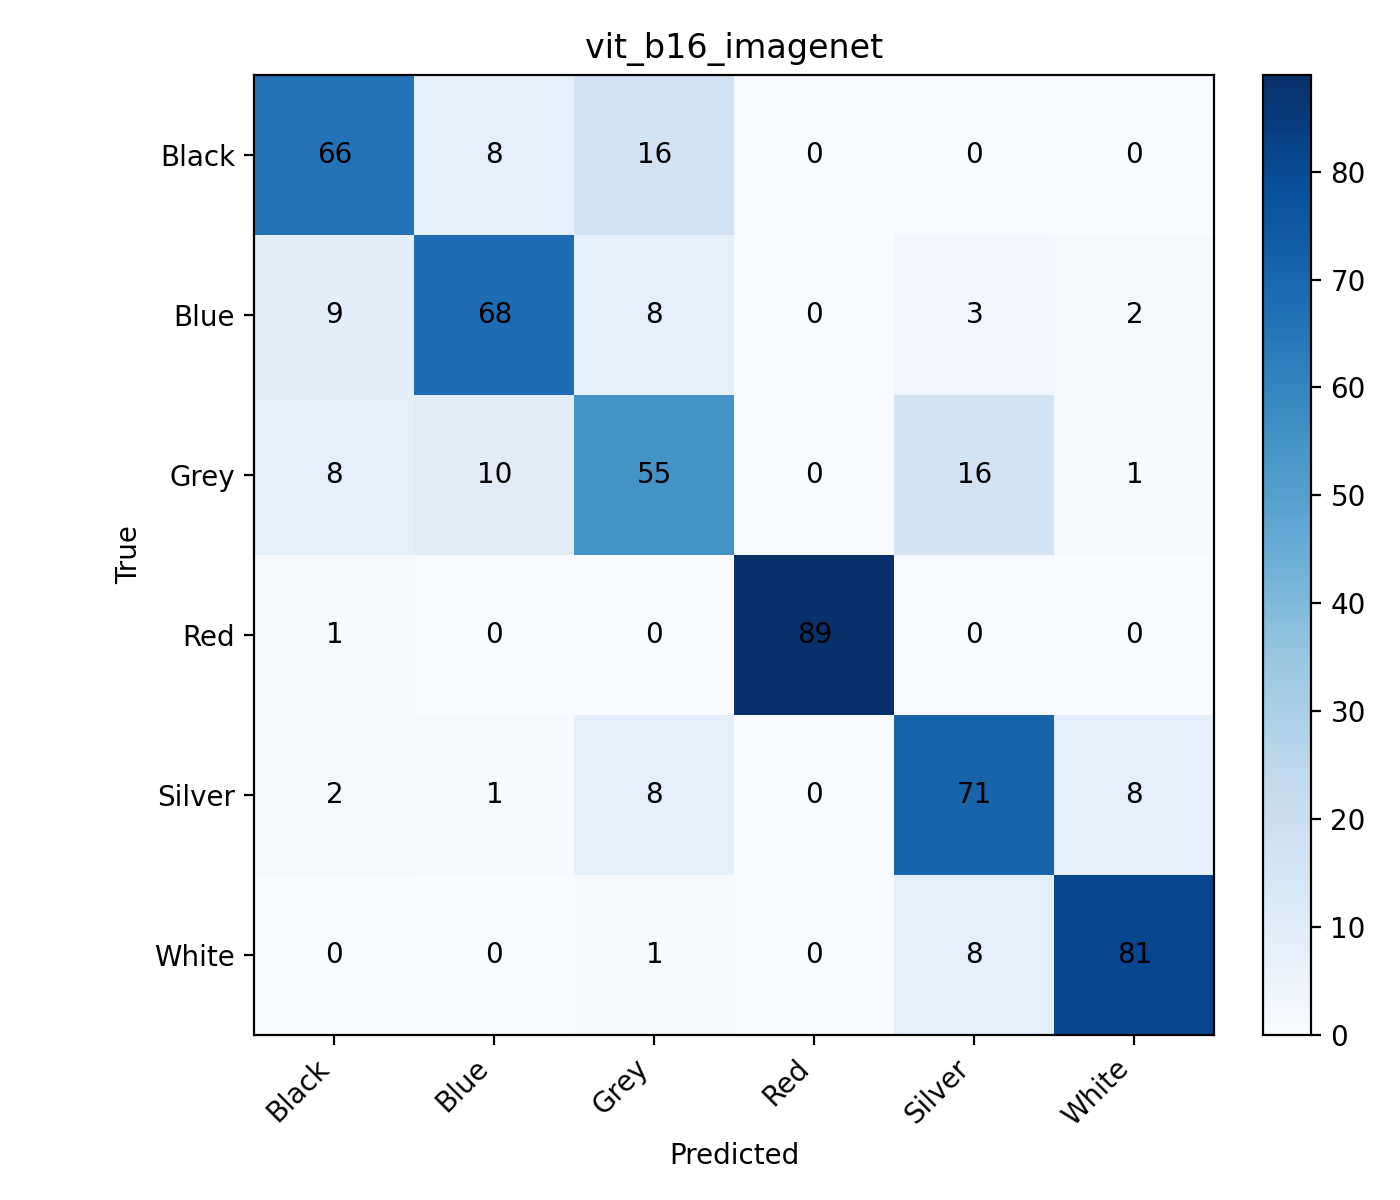

### ViT-B/16 SWAG

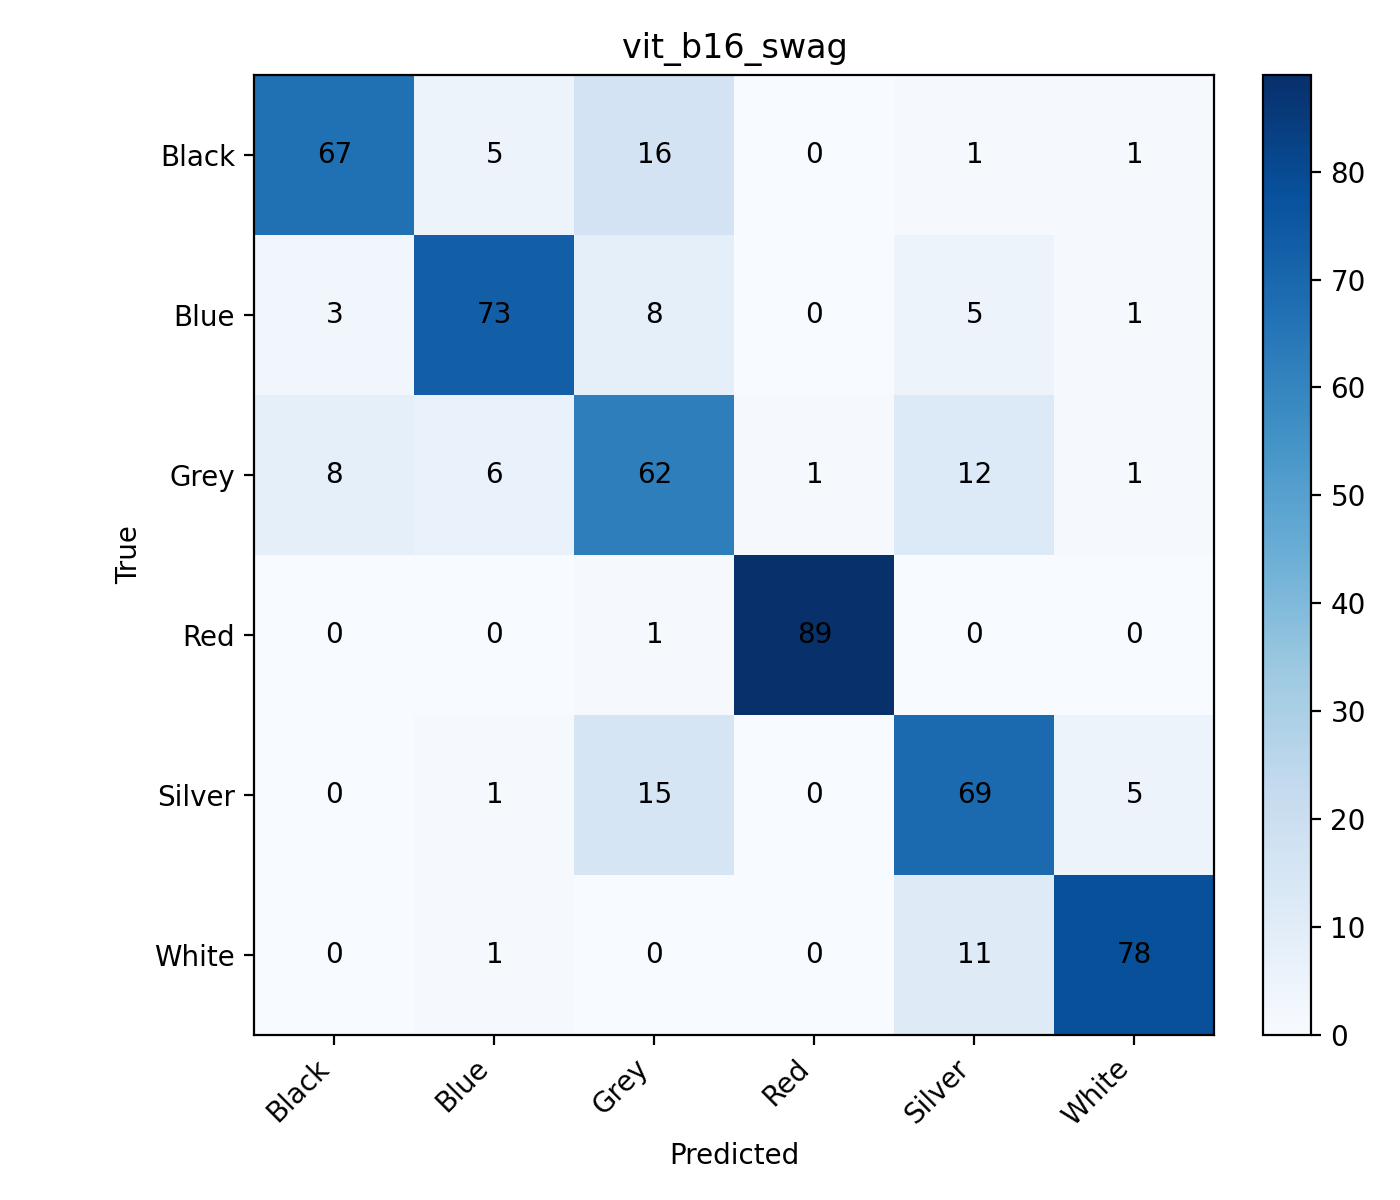

### Scratch CNN

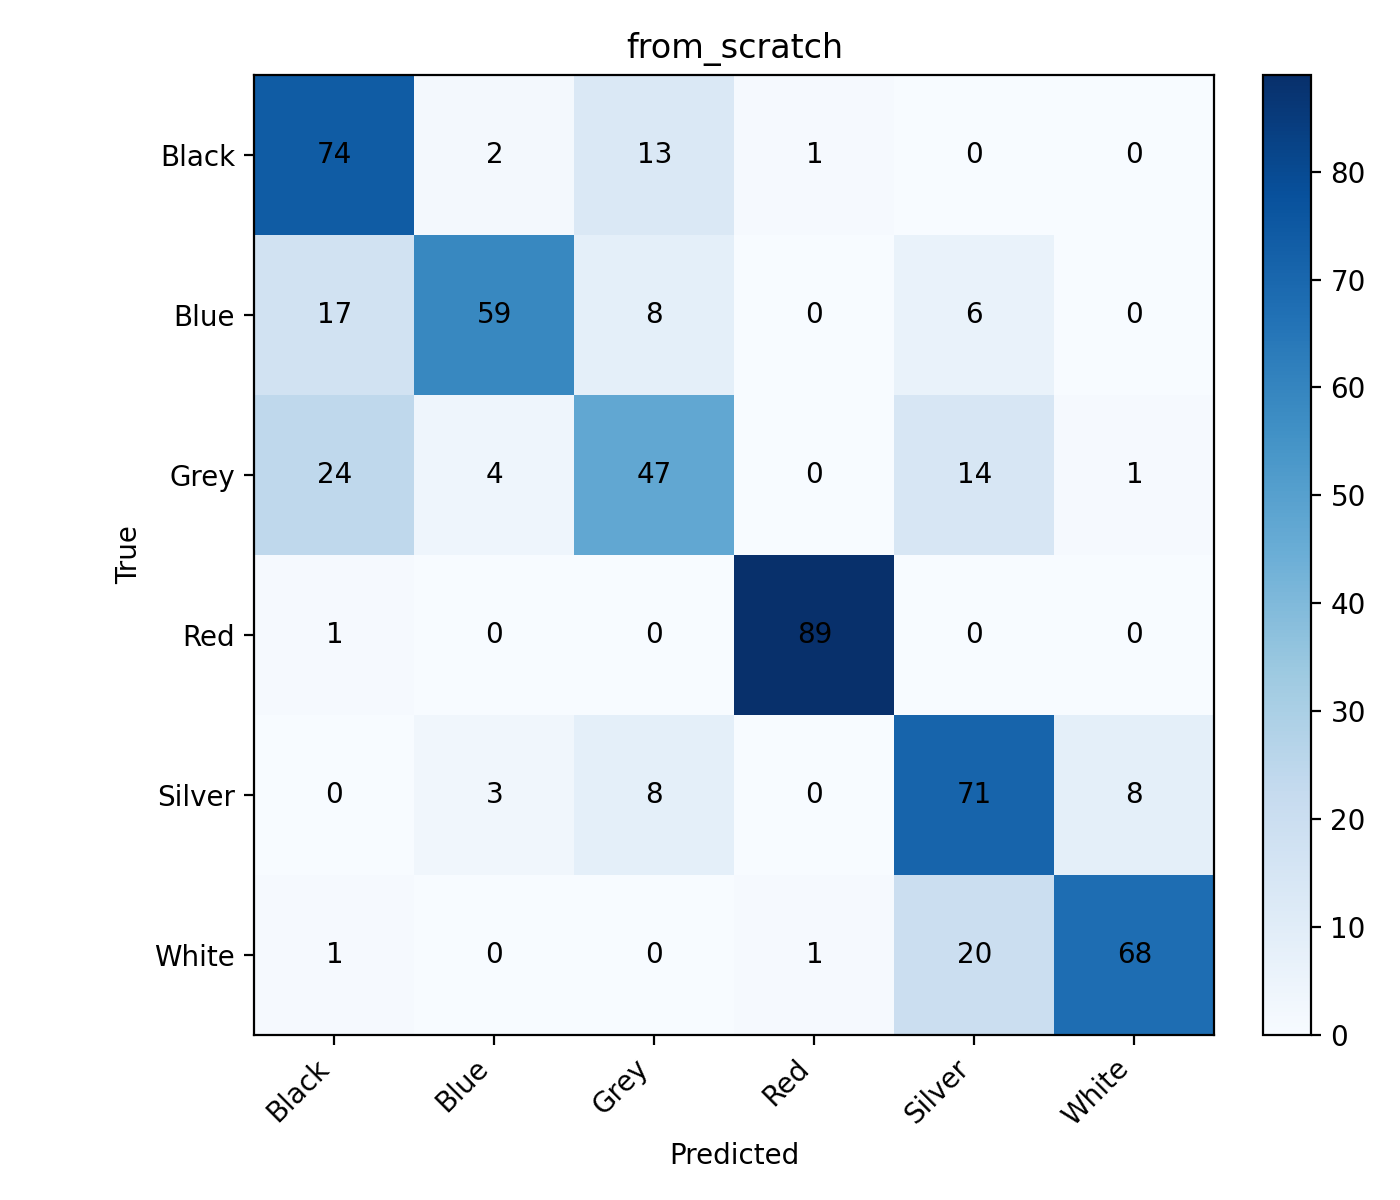

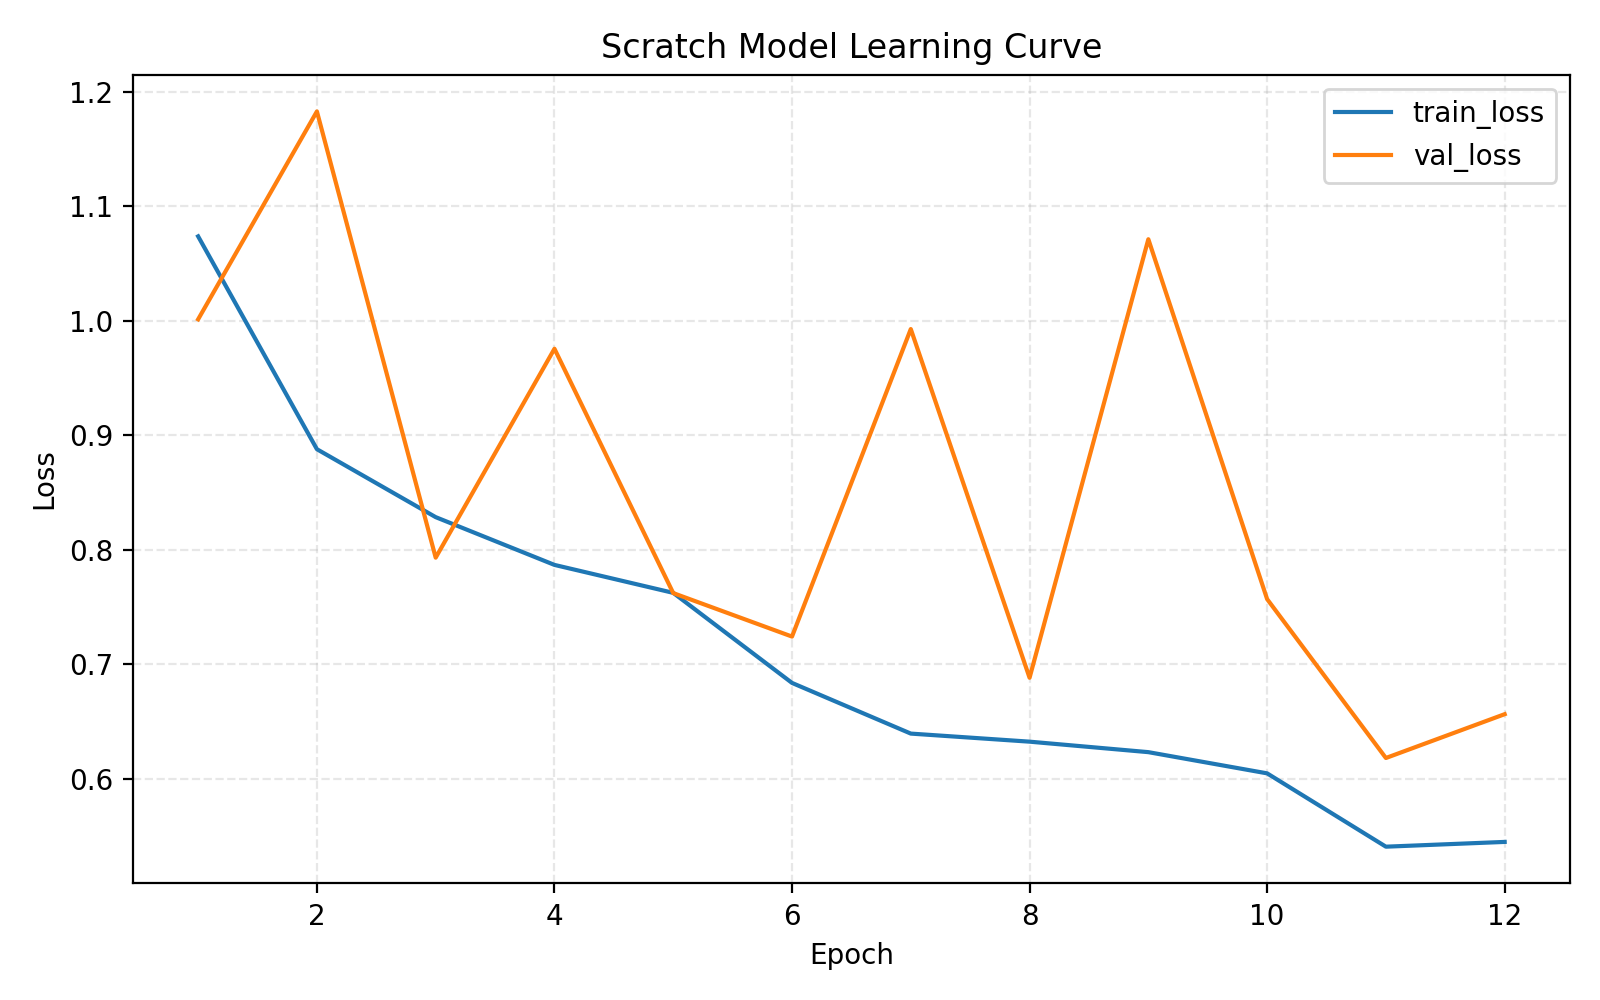

In [24]:
display(Markdown("### ViT-B/16 ImageNet"))
display(Image(filename=str(artifacts_root / "vit_b16_imagenet_confusion.png")))

display(Markdown("### ViT-B/16 SWAG"))
display(Image(filename=str(artifacts_root / "vit_b16_swag_confusion.png")))

display(Markdown("### Scratch CNN"))
display(Image(filename=str(artifacts_root / "from_scratch_confusion.png")))
display(Image(filename=str(artifacts_root / "scratch_learning_curve.png")))

## Своя модель с нуля

Архитектура специально сделана компактной, потому что датасет небольшой и задача не требует глубокой сети с большим числом параметров.

In [25]:
import torch
from torch import nn

class ScratchClassifier(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        outputs = self.features(inputs)
        return self.classifier(outputs)

scratch_model = ScratchClassifier(num_classes=len(manifest["classes"]))
scratch_model

ScratchClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): Bat

In [26]:
display(pd.DataFrame([scratch_stats]))
display(scratch_history.tail())

,model,image_size,epochs_trained,best_epoch,parameter_count
0,scratch_cnn,128,12,11,390918


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro
7,8,0.632212,0.688052,0.724074,0.728607
8,9,0.623047,1.071329,0.603704,0.582483
9,10,0.604516,0.756796,0.681481,0.667205
10,11,0.540428,0.617929,0.770370,0.769263
11,12,0.544593,0.656234,0.755556,0.754958


## Вывод

Лучший результат показала модель `vit_b16_swag`.

`F1_macro` здесь важен тем, что усредняет качество по всем цветам и не позволяет одному классу слишком сильно влиять на итоговую оценку.

In [27]:
display(pd.DataFrame([conclusion]))

best_gap = float(summary.iloc[0]["test_f1_macro"] - summary.iloc[-1]["test_f1_macro"])
display(Markdown(f"**Разница между лучшей и худшей моделью по F1_macro:** {best_gap:.4f}"))

,best_model,best_test_f1_macro,worst_model,worst_test_f1_macro,quality_interpretation,device,elapsed_minutes
0,vit_b16_swag,0.813715,scratch_cnn,0.75539,F1_macro averages F1 across all color classes ...,cpu,17.9


**Разница между лучшей и худшей моделью по F1_macro:** 0.0583